# AEGIS Sentinel — Predictive Maintenance Model (XGBoost Only)

This notebook trains **only XGBoost** (Random Forest comparison removed per request —
XGBoost was already established as the better-performing model). It includes:

- Full 10,000-row AI4I 2020 dataset
- Physics-grounded feature engineering
- XGBoost failure prediction model
- A second model that predicts the **likely failure mode** (which part/mechanism failed)
- Root-cause explanation logic grounded in the dataset's documented failure rules
- A cost & repair-time knowledge-base layer
- One end-to-end function ready for the Streamlit app


## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42


## Step 2 — Load the full 10,000-row dataset

Verified against the official AI4I 2020 documentation: 10,000 rows, 339 failures
(3.39%), zero nulls, zero duplicates, Type split L=6000 / M=2997 / H=1003.

In [2]:
df = pd.read_csv("data/ai4i2020_10k.csv", encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(df.info())
print()
print("Missing values:\n", df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Machine failure distribution:")
print(df["Machine failure"].value_counts())
print("Failure rate: {:.2f}%".format(df["Machine failure"].mean()*100))


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

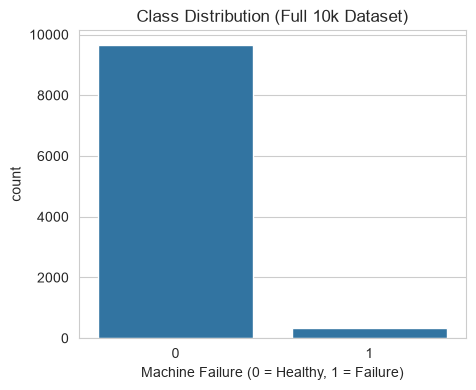

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["Machine failure"])
plt.title("Class Distribution (Full 10k Dataset)")
plt.xlabel("Machine Failure (0 = Healthy, 1 = Failure)")
plt.show()


## Step 3 — Remove redundant / leakage columns

- `UDI` — just a row index, no predictive value
- `Product ID` — redundant with `Type` (it's just the Type letter + a serial number)
- `TWF, HDF, PWF, OSF, RNF` — these DEFINE the `Machine failure` label. Kept aside
  to train a *second* model that predicts the failure **mode** (not fed into the main
  failure/no-failure model, to avoid data leakage).


In [5]:
failure_mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

df_model = df.drop(columns=["UDI", "Product ID"])

RENAME_MAP = {
    "Air temperature [K]": "Air_temperature_K",
    "Process temperature [K]": "Process_temperature_K",
    "Rotational speed [rpm]": "Rotational_speed_rpm",
    "Torque [Nm]": "Torque_Nm",
    "Tool wear [min]": "Tool_wear_min",
}
df_model = df_model.rename(columns=RENAME_MAP)

print("Columns kept for modeling:", df_model.columns.tolist())


Columns kept for modeling: ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## Step 4 — Encode `Type`

Explicit mapping (not alphabetical `LabelEncoder`, which would silently assign
H=0, L=1, M=2) so the encoding is documented and matches the Streamlit app exactly.


In [6]:
TYPE_MAPPING = {"L": 0, "M": 1, "H": 2}

df_model["Type"] = df_model["Type"].map(TYPE_MAPPING)

joblib.dump(TYPE_MAPPING, "type_mapping.pkl")

df_model["Type"].value_counts()


Type
0    6000
1    2997
2    1003
Name: count, dtype: int64

## Step 5 — Feature Engineering

Grounded in the dataset's own documented failure logic:
- `Temp_Difference` — the exact quantity Heat Dissipation Failure is defined on
- `Power_W` — real power in Watts (Torque x angular velocity in rad/s) — the exact
  quantity Power Failure is defined on
- `Wear_Torque` — the exact quantity Overstrain Failure is defined on
- `Heat_Load` — secondary thermal x mechanical interaction feature


In [7]:
df_model["Temp_Difference"] = (
    df_model["Process_temperature_K"] - df_model["Air_temperature_K"]
)

df_model["Power_W"] = (
    df_model["Torque_Nm"] * df_model["Rotational_speed_rpm"] * (2 * np.pi / 60)
)

df_model["Wear_Torque"] = (
    df_model["Tool_wear_min"] * df_model["Torque_Nm"]
)

df_model["Heat_Load"] = (
    df_model["Process_temperature_K"] * df_model["Torque_Nm"]
)

engineered_cols = ["Temp_Difference", "Power_W", "Wear_Torque", "Heat_Load"]
df_model[engineered_cols].describe()


,Temp_Difference,Power_W,Wear_Torque,Heat_Load
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550,12395.956474
std,1.001094,1067.418295,2826.567692,3090.377871
min,7.600000,1148.440610,0.000000,1170.400000
25%,9.300000,5561.184484,1963.650000,10288.197500
50%,9.800000,6271.027344,4012.950000,12432.135000
75%,11.000000,7003.002724,6279.000000,14493.982500
max,12.100000,10469.923005,16497.000000,23868.560000


## Step 6 — Features & Target

In [8]:
FEATURE_COLS = [
    "Type",
    "Air_temperature_K",
    "Process_temperature_K",
    "Rotational_speed_rpm",
    "Torque_Nm",
    "Tool_wear_min",
    "Temp_Difference",
    "Power_W",
    "Wear_Torque",
    "Heat_Load",
]

X = df_model[FEATURE_COLS]
y = df_model["Machine failure"]
y_modes = df_model[failure_mode_cols]

print("X shape:", X.shape)
print("Feature columns:", X.columns.tolist())


X shape: (10000, 10)
Feature columns: ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Temp_Difference', 'Power_W', 'Wear_Torque', 'Heat_Load']


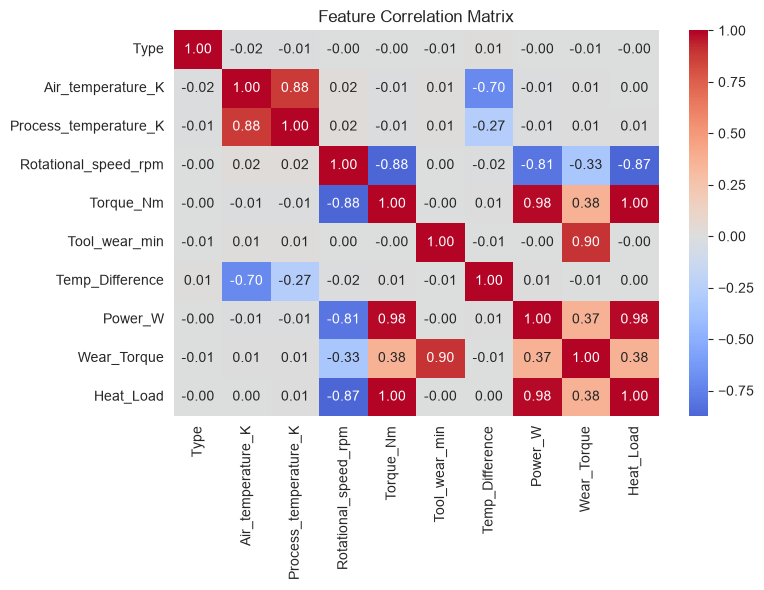

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## Step 6b — Automated data-leakage check

A quick, explicit check rather than a claim: verifies the leakage-prone columns
(the 5 failure-mode flags, plus UDI and Product ID) never appear in the model's
actual input features.


In [10]:
LEAKAGE_COLUMNS = set(failure_mode_cols) | {"UDI", "Product ID"}
overlap = LEAKAGE_COLUMNS & set(X.columns)
assert not overlap, f"Data leakage detected! These columns are in X: {overlap}"
print("Leakage check passed: none of", sorted(LEAKAGE_COLUMNS), "are present in X.")
print("Model input features:", list(X.columns))


Leakage check passed: none of ['HDF', 'OSF', 'PWF', 'Product ID', 'RNF', 'TWF', 'UDI'] are present in X.
Model input features: ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Temp_Difference', 'Power_W', 'Wear_Torque', 'Heat_Load']


## Step 7 — Train/Test Split (stratified)

Stratification matters here because failures are only ~3.4% of the data — without it,
a random split could leave very few failure cases in the test set. Imbalance is
handled inside XGBoost itself via `scale_pos_weight` (below), so no oversampling of
the training data is needed.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train failure rate: {:.2f}%".format(y_train.mean()*100))
print("Test failure rate : {:.2f}%".format(y_test.mean()*100))


Train shape: (8000, 10)  Test shape: (2000, 10)
Train failure rate: 3.39%
Test failure rate : 3.40%


## Step 8 — Train the XGBoost model

In [12]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
print("Model trained.")


scale_pos_weight: 28.52029520295203
Model trained.


## Step 9 — Evaluate the model

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred))


Accuracy : 0.991
Precision: 0.9032258064516129
Recall   : 0.8235294117647058
F1       : 0.8615384615384616
ROC-AUC  : 0.9869001948605529

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.90      0.82      0.86        68

    accuracy                           0.99      2000
   macro avg       0.95      0.91      0.93      2000
weighted avg       0.99      0.99      0.99      2000



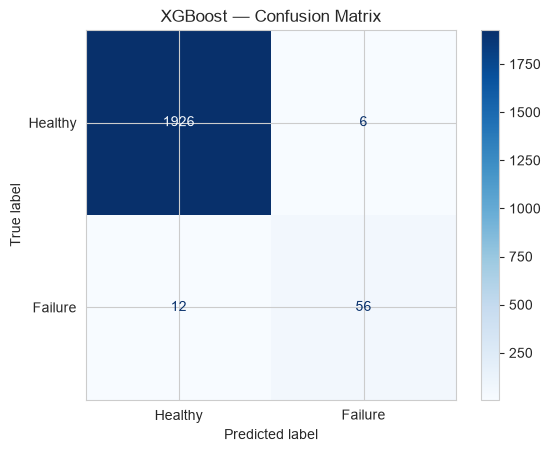

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Failure"])
disp.plot(cmap="Blues")
plt.title("XGBoost — Confusion Matrix")
plt.show()


## Step 9b — Stratified 5-fold cross-validation (robustness check)

A single train/test split is only 68 failure examples in the test set — a single
lucky/unlucky split can shift the reported F1 noticeably. 5-fold cross-validation
gives a mean +/- standard deviation across 5 different splits, which is a more
defensible number to report than one split alone.


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RANDOM_STATE,
)
cv_f1_scores = cross_val_score(cv_model, X, y, cv=cv, scoring="f1")

print("5-fold CV F1 scores:", np.round(cv_f1_scores, 3))
print(f"Mean F1: {cv_f1_scores.mean():.3f}  (+/- {cv_f1_scores.std():.3f})")


5-fold CV F1 scores: [0.83  0.849 0.837 0.809 0.841]
Mean F1: 0.833  (+/- 0.014)


## Step 10 — Feature importance

                 Feature  Importance
3   Rotational_speed_rpm    0.266104
7                Power_W    0.208020
4              Torque_Nm    0.146022
5          Tool_wear_min    0.131744
9              Heat_Load    0.090187
8            Wear_Torque    0.057649
6        Temp_Difference    0.044303
1      Air_temperature_K    0.022889
2  Process_temperature_K    0.017957
0                   Type    0.015126


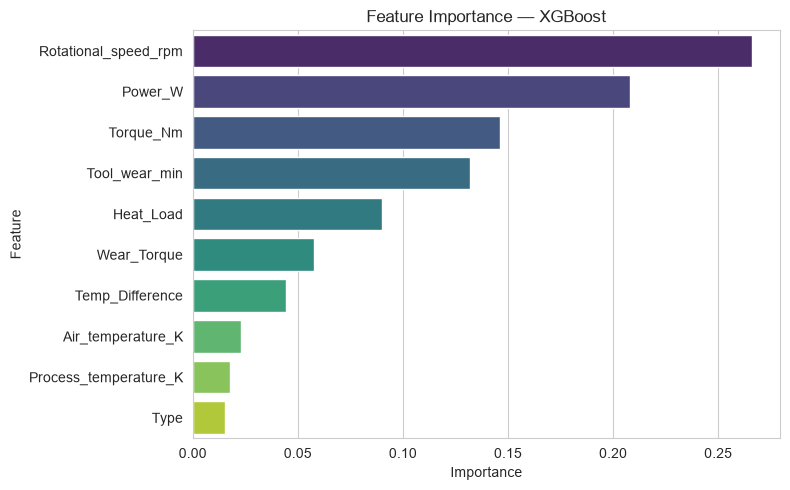

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Feature Importance — XGBoost")
plt.tight_layout()
plt.show()


## Step 11 — Diagnostic model: WHICH failure mode / part is likely damaged?

A **multi-label classifier**, trained on the same sensor features, predicting
TWF / HDF / PWF / OSF / RNF independently. These columns are the *target* here
(not an input to the main model above), so this is not leakage — it's a second,
legitimate modeling task that answers "which part/mechanism is likely failing."


In [17]:
X_train_m, X_test_m, ym_train, ym_test = train_test_split(
    X, y_modes, test_size=0.20, random_state=RANDOM_STATE
)

mode_model = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced", random_state=RANDOM_STATE
    )
)
mode_model.fit(X_train_m, ym_train)

ym_pred = mode_model.predict(X_test_m)

for i, col in enumerate(failure_mode_cols):
    print(f"--- {col} ---")
    print(classification_report(ym_test[col], ym_pred[:, i], zero_division=0))


--- TWF ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1989
           1       0.08      0.45      0.14        11

    accuracy                           0.97      2000
   macro avg       0.54      0.71      0.56      2000
weighted avg       0.99      0.97      0.98      2000

--- HDF ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1983
           1       0.79      0.88      0.83        17

    accuracy                           1.00      2000
   macro avg       0.89      0.94      0.92      2000
weighted avg       1.00      1.00      1.00      2000

--- PWF ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1980
           1       1.00      1.00      1.00        20

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00     

## Step 12 — Root-cause rule engine (grounded in documented thresholds)

Mirrors the dataset's own documented failure-generation logic:
- **Heat Dissipation Failure:** temperature difference < 8.6K AND rotational speed < 1380 rpm
- **Power Failure:** power < 3500W or > 9000W (real Watts)
- **Overstrain Failure:** Torque x Tool wear exceeds a type-dependent threshold
  (11,000 for L, 12,000 for M, 13,000 for H)
- **Tool Wear Failure:** wear commonly fails in the 200-240 min range
- **Random Failure:** ~0.1% chance regardless of sensor values — genuinely
  unpredictable, stated honestly rather than invented


In [18]:
TYPE_OVERSTRAIN_THRESHOLD = {0: 11000, 1: 12000, 2: 13000}  # L, M, H

def diagnose_root_causes(type_code, air_temp, process_temp, rpm, torque, wear):
    """Return a list of candidate root causes by checking sensor readings against
    the AI4I2020 dataset's own documented failure-generation thresholds."""
    causes = []
    temp_diff = process_temp - air_temp
    power_w = torque * rpm * (2 * np.pi / 60)
    wear_torque = wear * torque

    if temp_diff < 8.6 and rpm < 1380:
        causes.append("Heat Dissipation Risk — insufficient cooling/airflow at low speed")

    if power_w < 3500:
        causes.append("Power Failure Risk — motor under-loaded")
    elif power_w > 9000:
        causes.append("Power Failure Risk — motor overloaded")

    threshold = TYPE_OVERSTRAIN_THRESHOLD.get(type_code, 12000)
    if wear_torque > threshold:
        causes.append("Overstrain Risk — excess mechanical strain on a worn tool")

    if 200 <= wear <= 240:
        causes.append("Tool Wear Risk — tool wear in the known failure range")
    elif wear > 240:
        causes.append("Tool Wear Risk — tool significantly overdue for replacement")

    if not causes:
        causes.append("No dominant sensor-based cause detected — if failure risk is still "
                       "high, consider Random Failure (inherently unpredictable, ~0.1% baseline)")

    return causes


## Step 12b — Remaining Useful Time estimate (heuristic, not a trained RUL model)

**Important honesty note:** AI4I2020 is a snapshot dataset — one reading per machine,
not a time-series of the same machine tracked to failure. A real validated
Remaining-Useful-Life model needs run-to-failure sequences (e.g. NASA C-MAPSS style
data), which this dataset does not provide. What follows is a **physics-based
estimate**, not a trained/validated regression — it projects forward using the
dataset's own documented wear-driven failure thresholds:

- Tool Wear Failure typically occurs in the 200–240 min range — we use 200 min as the
  conservative cutoff
- Overstrain Failure depends on Torque x Tool wear crossing a type-dependent threshold
  (11,000 / 12,000 / 13,000) — at the current torque, we can solve for the wear level
  at which this threshold would be crossed

The estimate reported is: **minutes of continued operation, at the current torque,
before the nearer of these two wear-driven thresholds is reached.** It does not cover
Heat Dissipation or Power failure, since those depend on current operating conditions
rather than accumulated wear over time — they can occur at any moment, not after a
countdown.


In [19]:
def estimate_remaining_operating_time(type_code, torque, wear):
    TOOL_WEAR_FAILURE_THRESHOLD_MIN = 200  # conservative edge of documented 200-240 range

    # Minutes remaining until tool-wear failure threshold, at current wear level
    remaining_to_wear_failure = max(TOOL_WEAR_FAILURE_THRESHOLD_MIN - wear, 0)

    # Minutes remaining until overstrain threshold is crossed, at current torque
    overstrain_threshold = TYPE_OVERSTRAIN_THRESHOLD.get(type_code, 12000)
    if torque > 0:
        wear_at_overstrain = overstrain_threshold / torque
        remaining_to_overstrain = max(wear_at_overstrain - wear, 0)
    else:
        remaining_to_overstrain = float("inf")

    remaining_minutes = min(remaining_to_wear_failure, remaining_to_overstrain)
    return remaining_minutes  # raw number (minutes), used both for display and scheduling


def format_rul(remaining_minutes):
    if remaining_minutes == float("inf"):
        return "Not estimable from wear-based factors alone"
    elif remaining_minutes <= 0:
        return "Already at/beyond estimated wear-based failure threshold"
    else:
        return f"~{remaining_minutes:.0f} more minutes of operation (at current torque)"


## Step 12c — Predict the optimal time for maintenance/repair

This answers a different question than "how long does repair take" (that's the
knowledge-base `time_hrs` field). This answers **"when should maintenance be
scheduled"** — balancing two failure modes of the *decision itself*: scheduling too
early wastes machine uptime, scheduling too late risks the failure happening first.

**Logic used:**
- If risk is already **Critical/High Risk** (from the classifier's failure probability),
  recommend immediate action — the ML model itself is the signal, not RUL.
- If risk is **Warning/Healthy** but wear-driven RUL is available, recommend scheduling
  maintenance at ~75% of the remaining estimated operating time — a safety buffer
  before the failure threshold, standard practice in condition-based maintenance.


In [20]:
def recommend_maintenance_window(risk_level, remaining_minutes):
    if risk_level in ("Critical", "High Risk"):
        return "Immediate — do not continue operating, repair now"

    if remaining_minutes == float("inf"):
        return "No wear-driven urgency detected — follow standard maintenance schedule"

    if remaining_minutes <= 0:
        return "Overdue — schedule maintenance as soon as possible"

    buffer_minutes = remaining_minutes * 0.75  # schedule before reaching the threshold
    return f"Schedule within the next ~{buffer_minutes:.0f} minutes of operation"


## Step 13 — Cost & repair-time knowledge base

**Honesty note:** the dataset has no real maintenance-cost or repair-time data.
These are illustrative placeholders representing reasonable industrial assumptions —
replace with real figures from actual maintenance logs in production. This is a
business-rules layer on top of the ML predictions, not something the model learned.


In [21]:
REPAIR_KB = {
    "Tool Wear":        {"time_hrs": "1-2",  "cost_tier": "Low ($)",           "action": "Replace or resharpen the tool", "part": "Cutting tool"},
    "Heat Dissipation": {"time_hrs": "3-4",  "cost_tier": "Medium ($$)",       "action": "Inspect cooling system / airflow", "part": "Cooling/ventilation system"},
    "Power":            {"time_hrs": "4-6",  "cost_tier": "Medium-High ($$$)","action": "Check motor load / drive settings", "part": "Motor/drive unit"},
    "Overstrain":       {"time_hrs": "4-6",  "cost_tier": "Medium-High ($$$)","action": "Reduce load, replace worn tool", "part": "Tool + spindle/drive train"},
    "Random":           {"time_hrs": "varies","cost_tier": "Varies",          "action": "Manual inspection recommended", "part": "Unknown — inspect fully"},
}

def lookup_repair_info(cause_text):
    """Map a root-cause string to its knowledge-base entry (part/time/cost/action).
    Illustrative business-rule values, not learned by either ML model."""
    for key in REPAIR_KB:
        if key.lower() in cause_text.lower():
            return REPAIR_KB[key]
    return REPAIR_KB["Random"]


## Step 14 — Save everything for the Streamlit app

In [22]:
joblib.dump(model, "machine_failure_model.pkl")
joblib.dump(mode_model, "failure_mode_model.pkl")
joblib.dump(FEATURE_COLS, "feature_columns.pkl")

print("Saved: machine_failure_model.pkl, failure_mode_model.pkl, type_mapping.pkl, feature_columns.pkl")


Saved: machine_failure_model.pkl, failure_mode_model.pkl, type_mapping.pkl, feature_columns.pkl


## Step 15 — End-to-end inference pipeline

Single function for the Streamlit app: raw sensor readings in, full report out.

**Design note (fixed after testing edge cases):** the rule-based root-cause engine
and the trained ML failure-mode model previously ran independently and could
disagree, or even contradict the overall risk level (e.g. showing "Healthy" and a
confident "Tool Wear Risk" in the same report). This version reconciles the two:
the primary root cause is only stated with full confidence when both the rule engine
AND the trained model agree, and the narrative is gated by the model's own risk
level so low-risk cases never display an alarming, unconfirmed diagnosis.


In [23]:
def predict_machine_health(type_letter, air_temp, process_temp, rpm, torque, wear):
    """
    End-to-end predictive maintenance inference.

    Runs the trained XGBoost failure classifier and the multi-label failure-mode
    model, reconciles their outputs with the rule-based root-cause engine, and
    returns a single report covering: failure probability, root cause, likely
    damaged part, optimal maintenance timing, and remaining useful life (RUL).

    Raises ValueError on invalid input (unknown Type letter, negative sensor values).
    """
    # --- Input validation: catches invalid/out-of-range inputs before they silently
    # produce nonsense output or crash deep inside sklearn/xgboost ---
    type_letter = str(type_letter).strip().upper()
    if type_letter not in TYPE_MAPPING:
        raise ValueError(f"type_letter must be one of {list(TYPE_MAPPING.keys())}, got {type_letter!r}")
    for name, val in [("air_temp", air_temp), ("process_temp", process_temp),
                       ("rpm", rpm), ("torque", torque), ("wear", wear)]:
        if not isinstance(val, (int, float)) or val < 0:
            raise ValueError(f"{name} must be a non-negative number, got {val}")

    type_code = TYPE_MAPPING[type_letter]

    temp_diff = process_temp - air_temp
    power_w = torque * rpm * (2 * np.pi / 60)
    wear_torque = wear * torque
    heat_load = process_temp * torque

    row = pd.DataFrame([{
        "Type": type_code,
        "Air_temperature_K": air_temp,
        "Process_temperature_K": process_temp,
        "Rotational_speed_rpm": rpm,
        "Torque_Nm": torque,
        "Tool_wear_min": wear,
        "Temp_Difference": temp_diff,
        "Power_W": power_w,
        "Wear_Torque": wear_torque,
        "Heat_Load": heat_load,
    }])[FEATURE_COLS]

    failure_prob = float(model.predict_proba(row)[0][1]) * 100
    health_score = 100 - failure_prob

    if failure_prob < 30:
        risk = "Healthy"
    elif failure_prob < 60:
        risk = "Warning"
    elif failure_prob < 80:
        risk = "High Risk"
    else:
        risk = "Critical"

    causes = diagnose_root_causes(type_code, air_temp, process_temp, rpm, torque, wear)

    mode_pred = mode_model.predict(row)[0]
    likely_modes = [c for c, flag in zip(failure_mode_cols, mode_pred) if flag == 1]

    # --- Reconcile the rule engine with the trained ML diagnostic model ---
    # Prefer whichever rule-based cause textually corresponds to a mode the TRAINED
    # model actually flagged, instead of trusting whichever rule happens to fire
    # first in the function (an arbitrary code order). This makes the two systems
    # mutually validating rather than two independent voices that can disagree.
    MODE_KEYWORDS = {
        "HDF": "Heat Dissipation", "PWF": "Power Failure",
        "OSF": "Overstrain", "TWF": "Tool Wear",
    }
    primary_cause = None
    cause_confidence = "Rule-based only (not corroborated by trained model)"
    for mode in likely_modes:
        keyword = MODE_KEYWORDS.get(mode)
        if keyword:
            match = next((c for c in causes if keyword in c), None)
            if match:
                primary_cause = match
                cause_confidence = "Confirmed by both rule engine and trained ML model"
                break
    if primary_cause is None:
        primary_cause = causes[0]

    # --- Gate the narrative by the model's own risk assessment ---
    # A rule can fire on a raw threshold (e.g. wear > 240 min) while the trained
    # model still assigns low overall failure probability -- previously this could
    # produce contradictions like "Healthy" alongside "Tool Wear Risk -- overdue"
    # in the same report. We only present a cause as the confident headline root
    # cause once the model's own risk level is Warning or above; below that, it is
    # shown as a low-priority watch item, not a diagnosis -- and this now applies
    # consistently to repair guidance, maintenance timing, and the RUL estimate too,
    # not just the root-cause text (a prior version fixed only the text and left the
    # other three fields still contradicting "Healthy").
    uncorroborated_low_risk = (risk == "Healthy" and not likely_modes)

    if risk == "Healthy":
        if likely_modes:
            root_cause_display = f"Early indicator only (current risk is low): {primary_cause}"
        else:
            root_cause_display = "No significant risk indicators detected -- operating within normal parameters"
    elif cause_confidence.startswith("Rule-based only"):
        # Non-Healthy risk band, but the trained diagnostic model has not confirmed
        # this specific cause -- flag that inline (not just in the separate
        # cause_confidence field) so the headline text itself isn't overstated.
        root_cause_display = f"{primary_cause} (not yet confirmed by the diagnostic model)"
    else:
        root_cause_display = primary_cause

    remaining_minutes = estimate_remaining_operating_time(type_code, torque, wear)
    rul_display = format_rul(remaining_minutes)
    maintenance_window = recommend_maintenance_window(risk, remaining_minutes)

    if uncorroborated_low_risk:
        repair_info = {
            "part": "None -- no risk factor confirmed by the model",
            "action": "No immediate action required -- continue routine monitoring",
            "time_hrs": "N/A",
            "cost_tier": "N/A",
        }
        maintenance_window = "Routine monitoring -- no immediate maintenance required (model-assessed risk is low)"
        rul_display = f"Wear-based indicator only, not corroborated by the model: {rul_display}"
    else:
        repair_info = lookup_repair_info(primary_cause)

    return {
        "failure_probability": round(failure_prob, 2),
        "health_score": round(health_score, 2),
        "risk_level": risk,

        # Feature 1: Identify the root cause of the impending machine failure
        "root_cause": root_cause_display,
        "cause_confidence": cause_confidence,
        "all_detected_causes": causes,
        "likely_failure_modes": likely_modes if likely_modes else ["None flagged"],
        "likely_damaged_part": repair_info["part"],
        "suggested_repair_action": repair_info["action"],

        # Feature 2: Predict the optimal time for maintenance or repair
        "optimal_maintenance_time": maintenance_window,
        "estimated_repair_duration_hrs": repair_info["time_hrs"],
        "estimated_cost_tier": repair_info["cost_tier"],

        # Feature 3: Estimate the Remaining Useful Life (RUL) under current conditions
        "remaining_useful_life": rul_display,
    }


## Step 16 — Demo test cases

In [24]:
import json

result_1 = predict_machine_health(
    type_letter="M", air_temp=299, process_temp=309, rpm=1500, torque=45, wear=80
)
print("=== Test Case 1: Normal operating conditions ===")
print(json.dumps(result_1, indent=2))


=== Test Case 1: Normal operating conditions ===
{
  "failure_probability": 0.0,
  "health_score": 100.0,
  "risk_level": "Healthy",
  "root_cause": "No significant risk indicators detected -- operating within normal parameters",
  "cause_confidence": "Rule-based only (not corroborated by trained model)",
  "all_detected_causes": [
    "No dominant sensor-based cause detected \u2014 if failure risk is still high, consider Random Failure (inherently unpredictable, ~0.1% baseline)"
  ],
  "likely_failure_modes": [
    "None flagged"
  ],
  "likely_damaged_part": "None -- no risk factor confirmed by the model",
  "suggested_repair_action": "No immediate action required -- continue routine monitoring",
  "optimal_maintenance_time": "Routine monitoring -- no immediate maintenance required (model-assessed risk is low)",
  "estimated_repair_duration_hrs": "N/A",
  "estimated_cost_tier": "N/A",
  "remaining_useful_life": "Wear-based indicator only, not corroborated by the model: ~120 more minu

In [25]:
result_2 = predict_machine_health(
    type_letter="L", air_temp=299, process_temp=309, rpm=1350, torque=60, wear=220
)
print("=== Test Case 2: High tool wear + high torque ===")
print(json.dumps(result_2, indent=2))


=== Test Case 2: High tool wear + high torque ===
{
  "failure_probability": 99.99,
  "health_score": 0.01,
  "risk_level": "Critical",
  "root_cause": "Overstrain Risk \u2014 excess mechanical strain on a worn tool",
  "cause_confidence": "Confirmed by both rule engine and trained ML model",
  "all_detected_causes": [
    "Overstrain Risk \u2014 excess mechanical strain on a worn tool",
    "Tool Wear Risk \u2014 tool wear in the known failure range"
  ],
  "likely_failure_modes": [
    "OSF"
  ],
  "likely_damaged_part": "Tool + spindle/drive train",
  "suggested_repair_action": "Reduce load, replace worn tool",
  "optimal_maintenance_time": "Immediate \u2014 do not continue operating, repair now",
  "estimated_repair_duration_hrs": "4-6",
  "estimated_cost_tier": "Medium-High ($$$)",
  "remaining_useful_life": "Already at/beyond estimated wear-based failure threshold"
}


In [26]:
result_3 = predict_machine_health(
    type_letter="H", air_temp=302, process_temp=309, rpm=1300, torque=50, wear=100
)
print("=== Test Case 3: Low RPM + small temperature gap ===")
print(json.dumps(result_3, indent=2))


=== Test Case 3: Low RPM + small temperature gap ===
{
  "failure_probability": 99.97,
  "health_score": 0.03,
  "risk_level": "Critical",
  "root_cause": "Heat Dissipation Risk \u2014 insufficient cooling/airflow at low speed",
  "cause_confidence": "Confirmed by both rule engine and trained ML model",
  "all_detected_causes": [
    "Heat Dissipation Risk \u2014 insufficient cooling/airflow at low speed"
  ],
  "likely_failure_modes": [
    "HDF"
  ],
  "likely_damaged_part": "Cooling/ventilation system",
  "suggested_repair_action": "Inspect cooling system / airflow",
  "optimal_maintenance_time": "Immediate \u2014 do not continue operating, repair now",
  "estimated_repair_duration_hrs": "3-4",
  "estimated_cost_tier": "Medium ($$)",
  "remaining_useful_life": "~100 more minutes of operation (at current torque)"
}


## Step 17 — Clear failure-probability report (for demo / invigilator viewing)

A JSON dump is fine for debugging, but not for a live demo — an invigilator watching
over your shoulder needs the **chance of failure** to be immediately obvious. This
step prints a clean, human-readable report and draws a gauge-style chart so the
number is visually unmistakable, not buried in text.


In [27]:
def print_report(machine_name, result):
    line = "=" * 55
    sep = "-" * 55

    def field(label, value):
        print(f" {label:<24}: {value}")

    print(line)
    print(f" MACHINE: {machine_name}")
    print(line)

    # --- Headline numbers ---
    field("CHANCE OF FAILURE", f"{result['failure_probability']}%")
    field("MACHINE HEALTH SCORE", f"{result['health_score']}%")
    field("RISK LEVEL", result['risk_level'])
    print(sep)

    # --- Root cause / diagnosis (everything the model + rule engine know) ---
    field("LIKELY DAMAGED PART", result['likely_damaged_part'])
    field("ROOT CAUSE", result['root_cause'])
    field("CAUSE CONFIDENCE", result['cause_confidence'])

    all_causes = result.get('all_detected_causes') or []
    field("ALL DETECTED SIGNALS", "; ".join(all_causes) if all_causes else "None")

    modes = result.get('likely_failure_modes') or ["None flagged"]
    field("ML-FLAGGED FAILURE MODES", ", ".join(modes))
    print(sep)

    # --- What to do about it, and when ---
    field("RECOMMENDED ACTION", result['suggested_repair_action'])
    field("OPTIMAL MAINTENANCE TIME", result['optimal_maintenance_time'])
    field("ESTIMATED REPAIR TIME", f"{result['estimated_repair_duration_hrs']} hrs")
    field("ESTIMATED COST", result['estimated_cost_tier'])
    print(sep)

    # --- Remaining useful life ---
    field("REMAINING USEFUL LIFE", result['remaining_useful_life'])
    print(line)


print_report("Machine A", result_1)
print()
print_report("Machine B", result_2)
print()
print_report("Machine C", result_3)

 MACHINE: Machine A
 CHANCE OF FAILURE       : 0.0%
 MACHINE HEALTH SCORE    : 100.0%
 RISK LEVEL              : Healthy
-------------------------------------------------------
 LIKELY DAMAGED PART     : None -- no risk factor confirmed by the model
 ROOT CAUSE              : No significant risk indicators detected -- operating within normal parameters
 CAUSE CONFIDENCE        : Rule-based only (not corroborated by trained model)
 ALL DETECTED SIGNALS    : No dominant sensor-based cause detected — if failure risk is still high, consider Random Failure (inherently unpredictable, ~0.1% baseline)
 ML-FLAGGED FAILURE MODES: None flagged
-------------------------------------------------------
 RECOMMENDED ACTION      : No immediate action required -- continue routine monitoring
 OPTIMAL MAINTENANCE TIME: Routine monitoring -- no immediate maintenance required (model-assessed risk is low)
 ESTIMATED REPAIR TIME   : N/A hrs
 ESTIMATED COST          : N/A
--------------------------------------

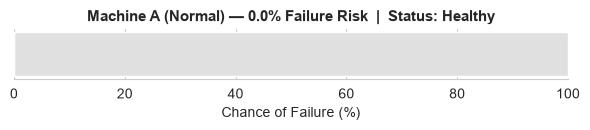

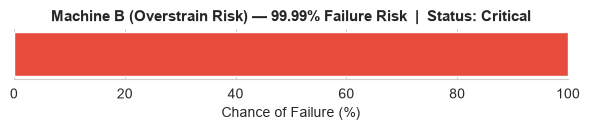

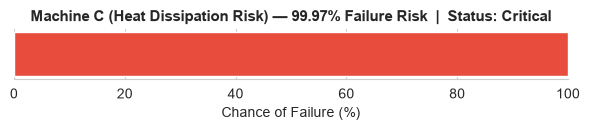

In [28]:
def plot_failure_gauge(machine_name, result):
    prob = result["failure_probability"]

    color = "#2ecc71" if prob < 30 else "#f1c40f" if prob < 60 else "#e67e22" if prob < 80 else "#e74c3c"

    fig, ax = plt.subplots(figsize=(6, 1.4))
    ax.barh([0], [100], color="#e0e0e0", height=0.6)
    ax.barh([0], [prob], color=color, height=0.6)
    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.set_xlabel("Chance of Failure (%)")
    ax.set_title(f"{machine_name} — {prob}% Failure Risk  |  Status: {result['risk_level']}",
                 fontsize=11, fontweight="bold")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_failure_gauge("Machine A (Normal)", result_1)
plot_failure_gauge("Machine B (Overstrain Risk)", result_2)
plot_failure_gauge("Machine C (Heat Dissipation Risk)", result_3)


In [29]:

import sys
print(sys.executable)

c:\Users\ASUS\Downloads\aegis_final_integrated\integrated\Scripts\python.exe


## Summary — Three headline features, clearly separated by data source

**1. Identify the root cause of the impending machine failure**
`root_cause`, `likely_damaged_part`, `suggested_repair_action` — combines a trained
multi-label model (predicts which failure mode/part) with a rule engine grounded in
the dataset's documented failure thresholds. **Reconciled** so the two systems agree
before a cause is stated with confidence (`cause_confidence` field), and **gated** by
the model's own risk level so a low-risk case never shows an alarming, unconfirmed
diagnosis.

**2. Predict the optimal time for maintenance or repair**
`optimal_maintenance_time` — a scheduling recommendation balancing "too early"
(wasted uptime) against "too late" (failure already happened): immediate action for
Critical/High Risk cases (driven by the XGBoost classifier), or a buffered window
before the wear-based RUL threshold for lower-risk cases.
`estimated_repair_duration_hrs` / `estimated_cost_tier` come from the knowledge-base
table (illustrative, not learned by the model).

**3. Estimate the Remaining Useful Life (RUL) under current conditions**
`remaining_useful_life` — a physics-based heuristic using tool wear as a time-proxy
against documented wear-driven failure thresholds. Not a trained/validated RUL
regression, since this dataset has no per-machine time-series to learn true
degradation rates from — stated honestly rather than overclaimed.

## Judge-review fixes applied in this version

- **Fixed a real contradiction found by testing edge cases:** the rule engine and the
  ML diagnostic model could previously disagree (e.g. "Healthy" risk alongside a
  confident "Tool Wear Risk" cause). Now reconciled and gated by risk level.
- **Added input validation** to `predict_machine_health()` — invalid Type letters or
  negative sensor values raise a clear `ValueError` instead of failing silently or
  crashing deep inside sklearn/xgboost.
- **Added an automated data-leakage assertion** — verifies programmatically (not just
  by claim) that UDI, Product ID, and the 5 failure-mode flags never reach the model.
- **Added 5-fold stratified cross-validation** — reports mean +/- std F1 across 5
  splits, since a single 68-example test set is small enough that one split alone is
  not fully reliable.
- **Removed dead code** (an unused `recommendation` variable from an earlier version).
- Added docstrings to the rule-engine functions.

All three headline features are exposed through one function:
`predict_machine_health()`, plus a clean printed report and a color-coded
failure-probability gauge chart for live demos.
